# Districts (with OSM data)

District should be derived using a car-based street network and for an area that is larger than the case study area (see below, e.g. for the city centre of London one should use Greater London)

In [10]:
import sys
from pathlib import Path

repo_root = Path.cwd().resolve().parents[1]
sys.path.insert(0, str(repo_root))

import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

fm.fontManager.addfont("times.ttf")
plt.rcParams["font.family"] = "Times New Roman"

import cityImage as ci

In [3]:
import osmnx as ox, networkx as nx, matplotlib.cm as cm, pandas as pd, numpy as np
import geopandas as gpd
from shapely.geometry import Point, mapping
%matplotlib inline

import warnings
warnings.simplefilter(action="ignore")
pd.options.display.float_format = '{:20.2f}'.format
pd.options.mode.chained_assignment = None

import cityImage as ci

## Functions from the cityImage API used in this notebook

This notebook derives *districts* (Lynch's regions) from a car-based street network by partitioning it into communities and turning those partitions into region polygons, then optionally assigns the districts back to a walkable network.

- [network_from_osm](../api/cityImage.network_from_osm.rst#cityImage.network_from_osm) — Download a street network from OpenStreetMap and return it as cityImage `nodes` and `edges` GeoDataFrames.
- [clean_network](../api/cityImage.clean_network.rst#cityImage.clean_network) — Clean and simplify the network: remove duplicate nodes/edges, pseudo-nodes, dead-ends and self-loops, and repair topology.
- [dual_gdf](../api/cityImage.dual_gdf.rst#cityImage.dual_gdf) — Build the dual-graph GeoDataFrames, where street segments become nodes (their centroids) and intersections become links.
- [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf) — Plot a single GeoDataFrame with cityImage styling.
- [dual_graph_fromGDF](../api/cityImage.dual_graph_fromGDF.rst#cityImage.dual_graph_fromGDF) — Build the dual NetworkX graph used for angular (dual) analysis.
- [identify_regions](../api/cityImage.identify_regions.rst#cityImage.identify_regions) — Identify districts/regions from a graph partition (community detection).
- [rand_cmap](../api/cityImage.rand_cmap.rst#cityImage.rand_cmap) — Build a random categorical colormap (useful for districts/partitions).
- [plot_grid_gdf_columns](../api/cityImage.plot_grid_gdf_columns.rst#cityImage.plot_grid_gdf_columns) — Plot several columns of one GeoDataFrame as a grid of maps.
- [polygonise_partitions](../api/cityImage.polygonise_partitions.rst#cityImage.polygonise_partitions) — Convert edge partitions into region polygons.
- [district_to_nodes_from_polygons](../api/cityImage.district_to_nodes_from_polygons.rst#cityImage.district_to_nodes_from_polygons) — Assign network nodes to districts using region polygons.
- [amend_nodes_membership](../api/cityImage.amend_nodes_membership.rst#cityImage.amend_nodes_membership) — Reassign nodes in disconnected districts to adjacent connected districts.
- [find_gateways](../api/cityImage.find_gateways.rst#cityImage.find_gateways) — Detect gateway nodes located at the boundary between districts.

For the full list of functions and their parameters, see the [API reference](../api.rst).

## Acquiring the Street Network

In [4]:
city_name = 'Muenster'
epsg = 25832
crs = 'EPSG:'+str(epsg)

**Download from OSM the **drive** network**

Choose between the following methods:

* `OSMplace`, provide an OSM place name (e.g. City).
* `polygon`, provide an WGS polygon of the case-study area.
* `distance_from_address`, provide a precise address and define parameter `distance` (which is otherwise not necessary)

In [5]:
place = 'Muenster, Germany'
download_method = 'OSMplace'
distance = None

nodes_graph, edges_graph = ci.network_from_osm(place, download_method=download_method, network_type="drive", crs=crs, distance=distance)
nodes_graph, edges_graph = ci.clean_network(nodes_graph, edges_graph, dead_ends = True, remove_islands = True,
                            self_loops = True, same_vertexes_edges = True)

# Creating and saving the dual geodataframes
nodesDual_graph, edgesDual_graph = ci.dual_gdf(nodes_graph, edges_graph, epsg)

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

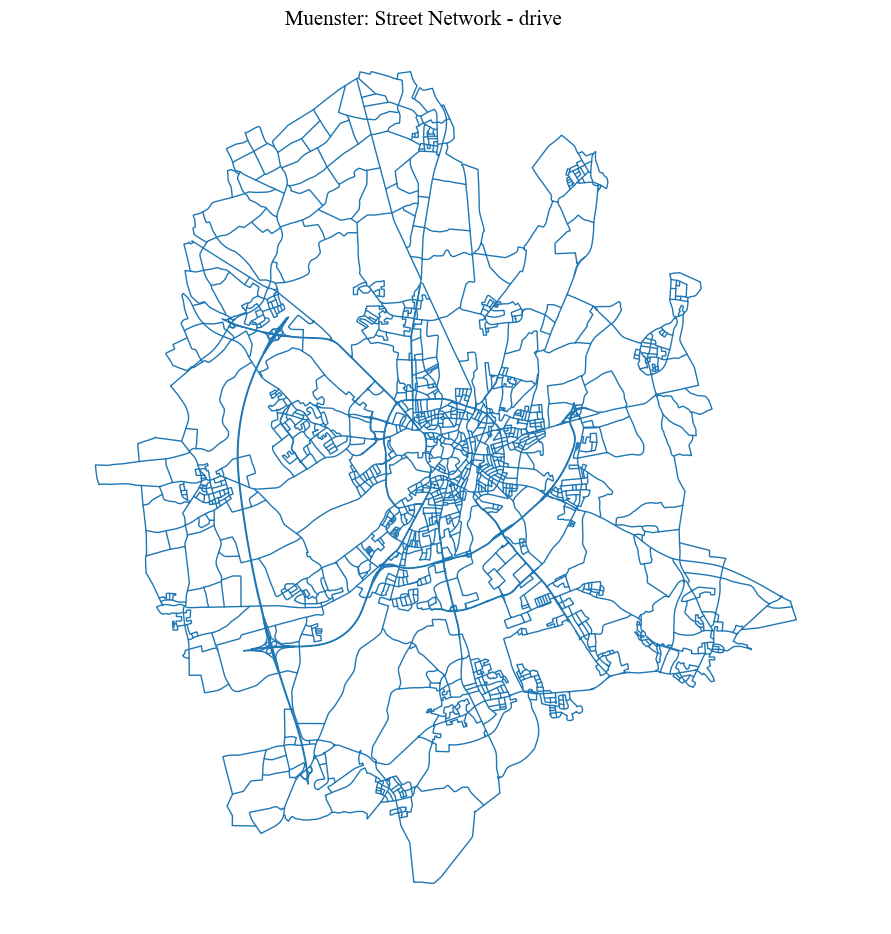

In [11]:
fig = ci.plot_gdf(edges_graph, black_background = False, figsize = (10,10), title = city_name+': Street Network - drive')

## District identification

In [7]:
# creating the dual_graph
dual_graph = ci.dual_graph_fromGDF(nodesDual_graph, edgesDual_graph)

Different weights can be used to extract the partitions. `None` indicates that no weights will be used 
(only topological relationships will matter). The function returns a GeoDataFrame with partitions assigned to edges,
with column named as `p_name_weight` (e.g. `p_length`).

In [12]:
!pip install python-louvain

  Using cached python_louvain-0.16-py3-none-any.whl


In [13]:
weights = ['length', 'rad', None]
districts = edges_graph.copy()
for weight in weights:
    districts = ci.identify_regions(dual_graph, districts, weight = weight)

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

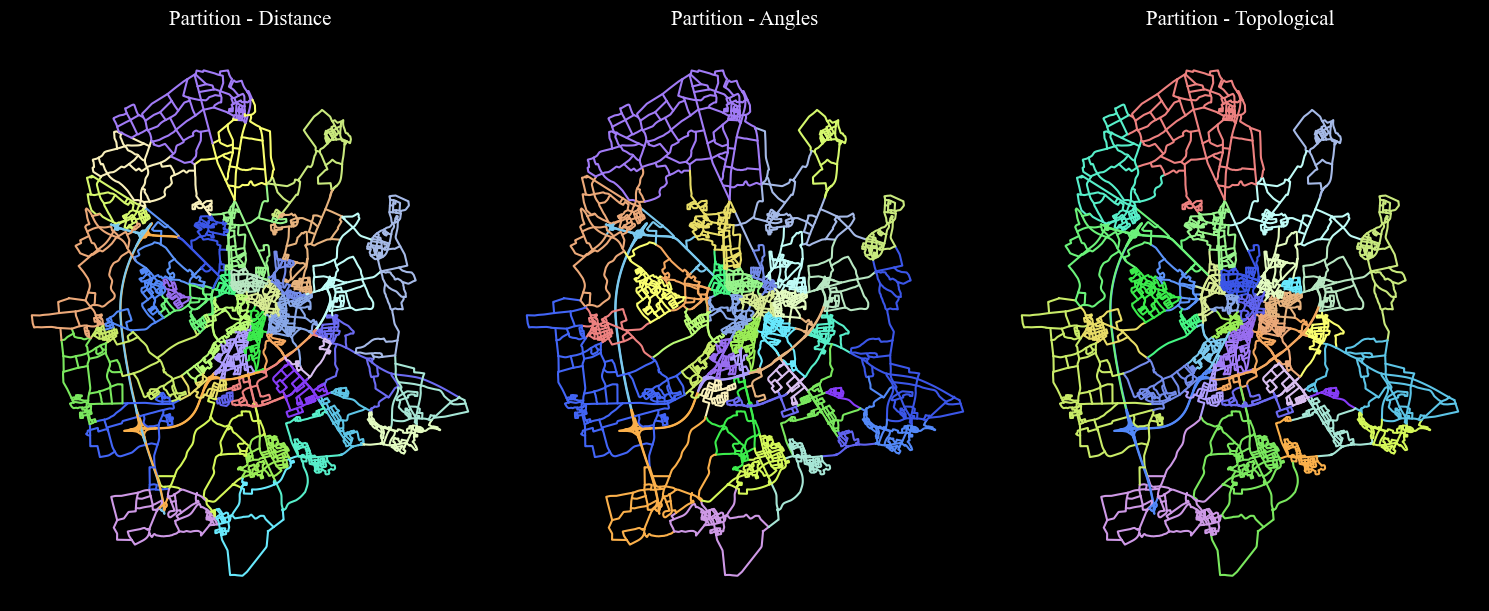

In [14]:
columns = ['p_length','p_rad', 'p_topo']
titles = ['Partition - Distance', 'Partition - Angles', 'Partition - Topological']

nlabels = max([len(districts[column].unique()) for column in columns])
cmap = ci.rand_cmap(nlabels = nlabels, type_color='bright')
fig = ci.plot_grid_gdf_columns(districts, columns = columns, titles = titles, geometry_size = 1.5, cmap = cmap, black_background = True, 
                  legend = False, figsize = (15, 10), ncols = 3, nrows = 1)

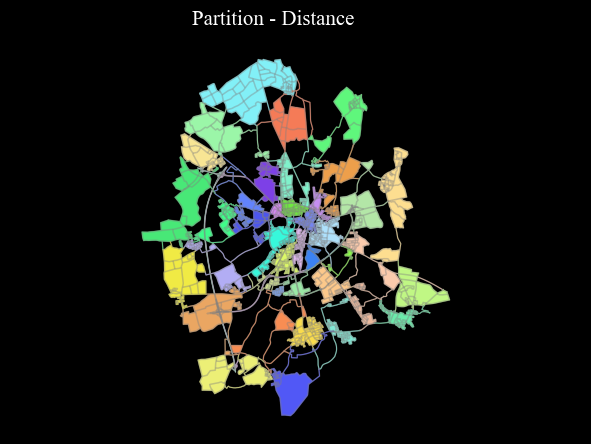

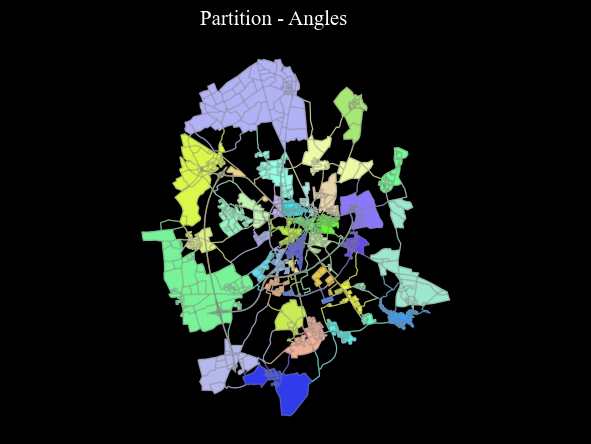

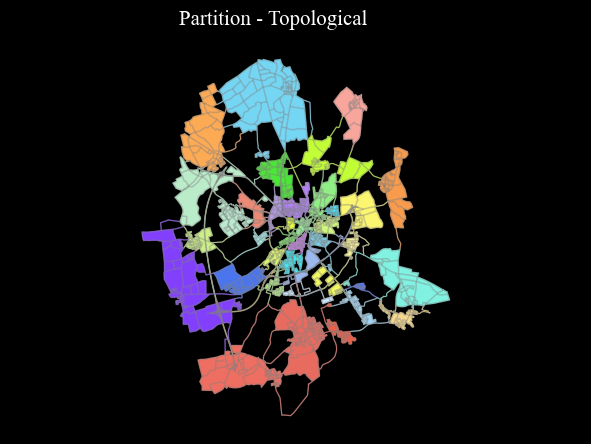

In [15]:
for n, column in enumerate(columns):
    cmap = ci.rand_cmap(nlabels = len(districts[column].unique()), type_color='bright')
    partitions = ci.polygonise_partitions(districts, column, convex_hull = False)
    ci.plot_gdf(partitions, column = column, cmap = cmap, title =  titles[n], black_background = True,  figsize = (7, 5), 
               base_map_gdf = districts, base_map_color = 'grey', base_map_zorder = 1)

**Exporting.** The results are written to disk as GeoPackage files with GeoPandas' `to_file`, ready to be reused in later notebooks or in external GIS software.

In [18]:
# provide path
from pathlib import Path

# provide path
output_dir = Path("../output")
output_dir.mkdir(parents=True, exist_ok=True)

output_file = output_dir / f"{city_name}_edges_districts.gpkg"
districts_export = districts.copy()
for col in districts_export.columns:
    if col != districts_export.geometry.name:
        districts_export[col] = districts_export[col].apply(
            lambda x: ", ".join(map(str, x)) if isinstance(x, (list, tuple, set)) else x
        )

districts_export.to_file(output_file, driver="GPKG")

## Assigning regions to the Pedestrian Street Network

**Case-study area (pedestrian walkable network)**

This set of functions assigns regions to a walkable network for further modelling in Pedestrian Simulation, for example.
The simply identification of regions (districts) from the urban configuration ends above.

**Get the pedestrian network from OSM:**

Choose between the following methods:

* `OSMplace`, provide an OSM place name (e.g. City).
* `polygon`, provide an WGS polygon of the case-study area.
* `distance_from_address`, provide a precise address and define parameter `distance` (which is otherwise not necessary)

In [19]:
place = 'Domplatz, Muenster, Germany' ## must be different from the area used for the drive network
download_method = 'distance_from_address'
distance = 2500

nodes_graph_ped, edges_graph_ped = ci.network_from_osm(place, download_method=download_method, network_type="walk", crs=crs, distance=distance)
nodes_graph_ped, edges_graph_ped = ci.clean_network(nodes_graph_ped, edges_graph_ped, dead_ends = True, 
                                remove_islands = True, self_loops = True, same_vertexes_edges = True)

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

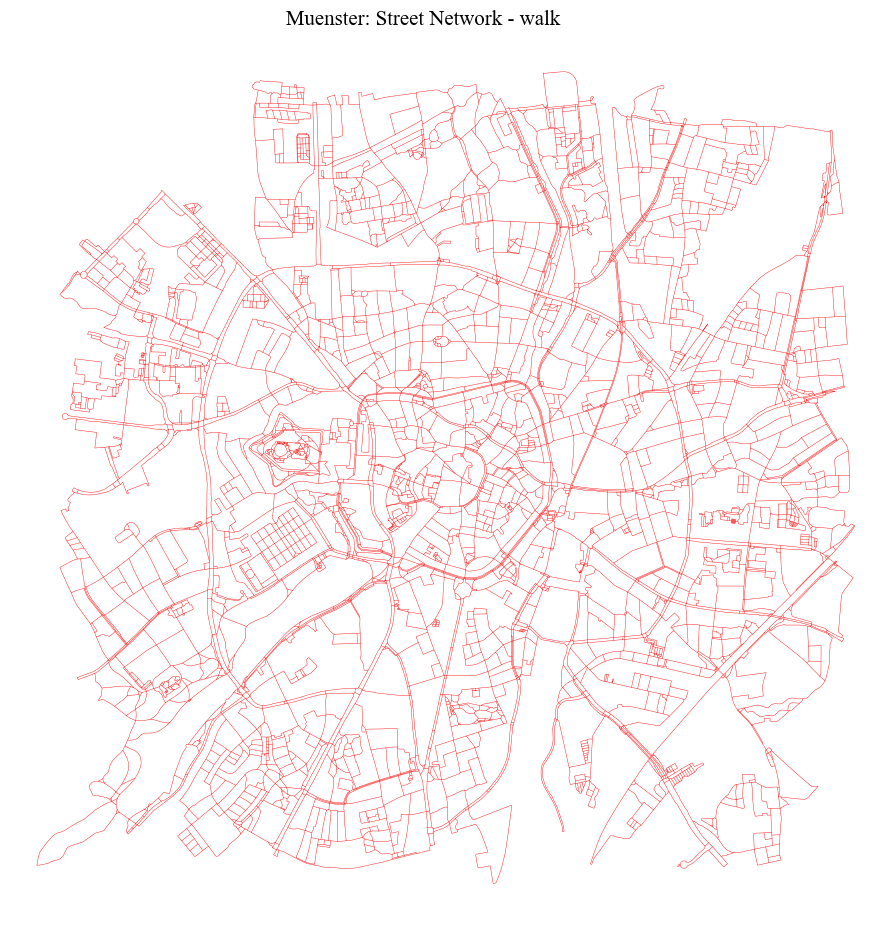

In [20]:
fig = ci.plot_gdf(edges_graph_ped, black_background = False, figsize = (10,10), title = city_name+': Street Network - walk',  
                  color = 'red', geometry_size = 0.3)

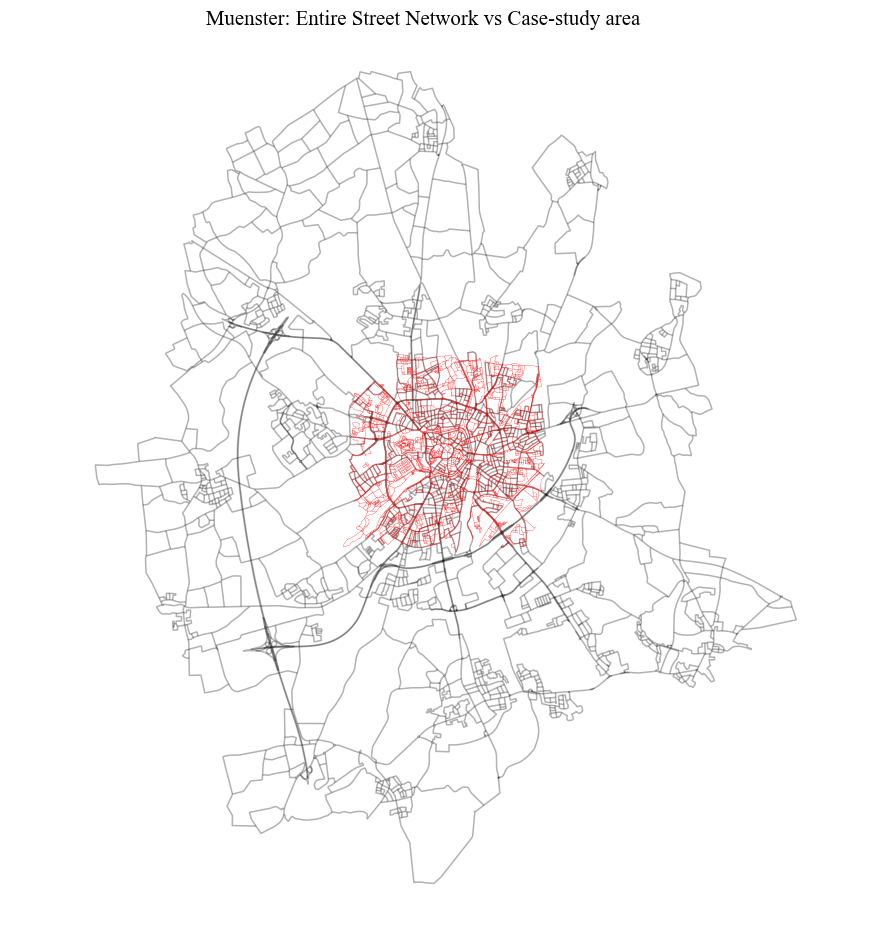

In [21]:
fig = ci.plot_gdf(edges_graph_ped, scheme = None,  black_background = False, figsize = (10,10), title = 
              city_name+': Entire Street Network vs Case-study area', color = 'red', geometry_size = 0.2,
             base_map_gdf = edges_graph, base_map_color = 'black', base_map_alpha = 0.3)

### Assigning nodes and edges in the pedestrian network to the Partitions

In [23]:
# choosing the type of partition to be used
column = 'p_length'
min_size_district = 10

In [24]:
dc = dict(districts[column].value_counts())

## ignore small portions
to_ignore = {k: v for k, v in dc.items() if v <= min_size_district} 
tmp = districts[~((districts[column].isin(to_ignore))| (districts[column] == 999999))].copy()

partitions = ci.polygonise_partitions(tmp, column)
nodes_graph_ped = ci.district_to_nodes_from_polygons(nodes_graph_ped, partitions, column)
nodes_graph_ped[column] = nodes_graph_ped[column].astype(int)

**Visualisation.** The cell below maps the result using the cityImage plotting helpers such as [plot_gdf](../api/cityImage.plot_gdf.rst#cityImage.plot_gdf); see the [Plotting section of the API reference](../api.rst) for all styling options.

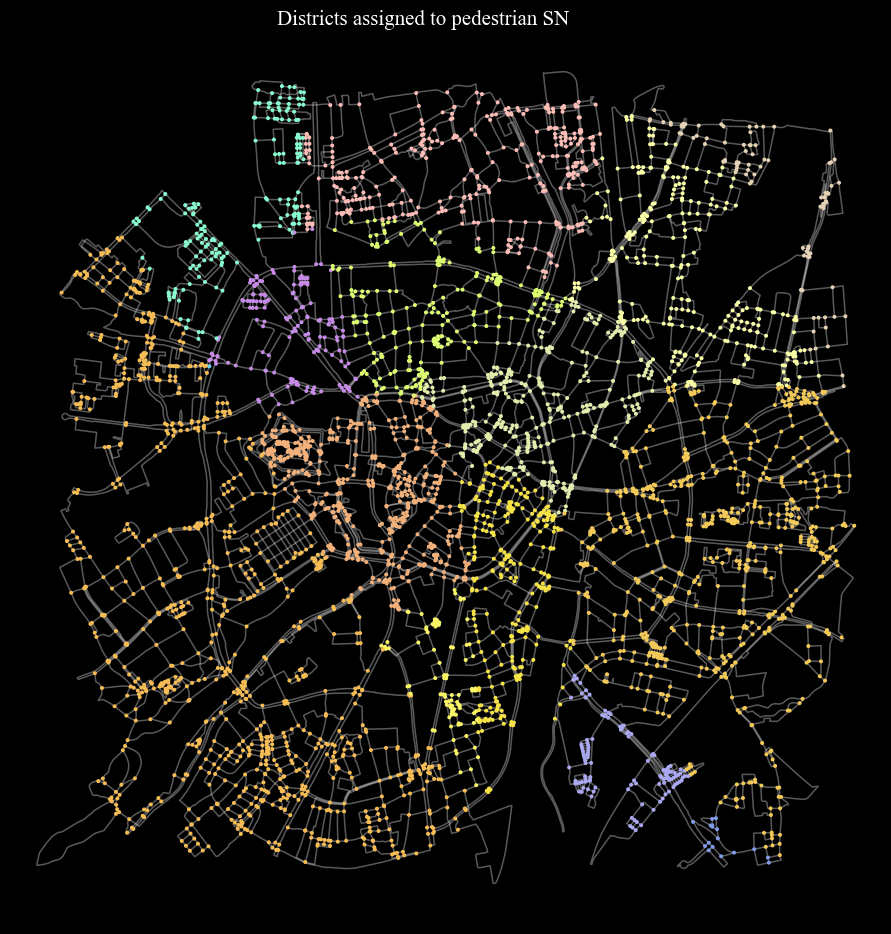

In [25]:
cmap = ci.rand_cmap(nlabels = len(nodes_graph_ped[column].unique()), type_color='bright')
fig = ci.plot_gdf(nodes_graph_ped, column = column, title = 'Districts assigned to pedestrian SN', cmap = cmap, 
                  geometry_size = 3.5, base_map_gdf = edges_graph_ped, base_map_color = 'white', base_map_alpha = 0.35,
                black_background = True, legend = False, figsize = (10,10))

### Fixing disconnected districts and assigning nodes to existing connected districts

In [26]:
nodes_graph_ped = ci.amend_nodes_membership(nodes_graph_ped, edges_graph_ped, column, min_size_district)
   
# assigning gateways
nodes_graph_ped = ci.find_gateways(nodes_graph_ped, edges_graph_ped, column)

### Final Sub-division in Districts/Regions

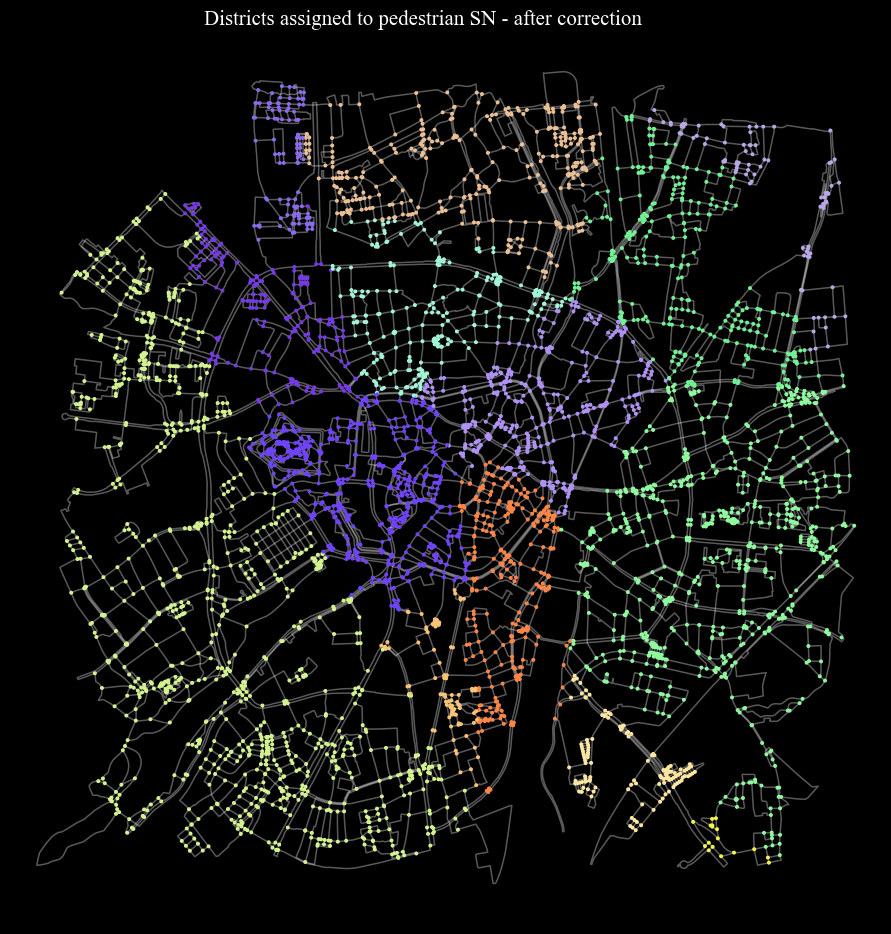

In [27]:
cmap = ci.rand_cmap(nlabels = len(nodes_graph_ped[column].unique()), type_color='bright')
fig = ci.plot_gdf(nodes_graph_ped, column = column, title = 'Districts assigned to pedestrian SN - after correction', 
               cmap = cmap, geometry_size = 3.5, base_map_gdf = edges_graph_ped, base_map_color = 'white', 
                  base_map_alpha = 0.35, black_background = True, legend = False, figsize = (10,10))

**Exporting.** The results are written to disk as GeoPackage files with GeoPandas' `to_file`, ready to be reused in later notebooks or in external GIS software.

In [29]:
nodes_graph_ped['district'] = nodes_graph_ped[column].astype(int)
nodes_graph_ped.to_file(output_path+"_nodes_ped.gpkg", driver="GPKG")
edges_graph_ped.to_file(output_path+"_edges_ped.gpkg", driver="GPKG")